<style>
/* blue background */
body, .container, .notebook-container {
  background-color:#cde4f7 !important;
  color:#1a1a1a !important;
}

/* Code + markdown styling */
div.input_area,
div.cell div.CodeMirror,
div.cell div.cm-editor,
div.cell div.CodeMirror-lines,
div.input_area pre,
div.cm-content,
div.cm-line {
  background-color:#ffffff !important;
  color:#000000 !important;
}

div.output_area {background:#ffffff !important; border-radius:6px; border:1px solid #d6e4ef;}
div.text_cell_render {background:white !important; color:#1a1a1a !important; line-height:1.6;}
div.cell {background:white !important; border:none !important;}
div.input {box-shadow:0 1px 3px rgba(0,0,0,0.05);}


/* Sidebar */
#toc-sidebar {
    position: fixed;
    top: 20px;                        
    left: 20px;                      
    width: 200px;
    padding: 20px;
    background: #e3e9eeff;                
    border: 1px solid #2673adff;        
    border-radius: 10px;             
    box-shadow: 0 2px 6px rgba(0,0,0,0.08); 
    max-height: 90%;
    overflow-y: auto;
    color: #1a1a1a;
}

/* Sidebar title */
#toc-sidebar h2 {
    font-size: 18px;
    margin-top: 0;
    margin-bottom: 15px;
}

/* Sidebar links */
#toc-sidebar a {
    color: #1a1a1a !important;
    text-decoration: none;
    font-size: 12px;
    margin-bottom: 10px;
    display: block;
}

/* Hover highlight */
#toc-sidebar a:hover {
    text-decoration: underline;
}

/* Push notebook content to the right */
body {
    margin-left: 260px !important; 
}
</style>


<!-- Sidebar HTML -->
<div id="toc-sidebar">
<h2>Contents</h2>

<a href="#Introduction">1. Introduction</a>
<a href="#Data-Cleaning">2. Data Cleaning</a>
<a href="#PLOT-1">3. Plot 1</a>
<a href="#PLOT-2">4. Plot 2</a>
<a href="#PLOT-3">5. Plot 3</a>
<a href="#Conclusion">6. Conclusion</a>
<a href="#References">7. Task Allocation</a>
<a href="#References">8. References</a>

</div>

# **Flights Analysis Project**

Done by: Khor Shi En Gabrielle, Ang Tze Yong Anthony, Shawn Ng Yu Shiun, Seah Jia En, Terence Tan Jing Cong

14/11/2025

# Introduction
Travel plays a significant role in global economic activity, with millions of people moving across borders each year for leisure and work. These movements, however, are not evenly distributed throughout the year. Instead, travel demand often fluctuates around key holiday periods, where cultural, national, and international calendars shape when people choose to embark on trips. Understanding these fluctuations is important, as they influence tourism revenue, transport planning, and the capacity management strategies of airlines and hospitality providers.

The dataset we will be using is the Global Holidays and Travel, provided by TidyTuesday which offers a comprehensive overview of global holidays alongside travel volumes across countries and regions. It brings together geographical and event-based information, allowing us to explore how global festivities may correspond with changes in travel behaviour. By examining patterns across different countries and time windows, our visualisations seek to answer the central question: How does the structure and period of holidays influence global air-travel activity? Through three visualisations, we aim to provide insights into the relationship between the holiday periods and global travel demand, offering a clearer understanding of how global holiday structures shape international travel from micro to macro level.

In [1]:
#import relevant packages
import os
import math
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import json

from plotnine import *

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

In [2]:
#Read in the 2 CSV that we read from tidytuesday
globalholidays = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-12-24/global_holidays.csv')
monthlypassengers = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-12-24/monthly_passengers.csv', na_values = ['NA'])

# Data Cleaning
Both datasets required several cleaning and transformation steps before analysis. For the global_holidays data, the `Date` column was first converted to a proper datetime format, enabling extraction of the corresponding `Year` and `Month` fields needed for merging with monthly passenger counts. Because the holiday dataset reports events at the individual-day level, the records were aggregated to the country-month level. This was done by grouping by `ADM_name`, `ISO3`, `Year`, and `Month`, and then collating all holiday names and types into lists. To quantify the intensity of holiday activity, a new variable `Holiday_Count` was created, counting only “significant” holidays (public holidays, local holidays, and special holidays). The monthly_passengers dataset contains monthly totals of domestic, international, and overall passenger movements. Since these values are essential for examining month-to-month changes, only rows with complete reporting of `Domestic` and `International` counts were retained. The holiday features were then merged into this monthly dataset using a left join on country, year, and month, ensuring that air-traffic data remained the backbone of the merged table. Any months with no recorded holidays were assigned a `Holiday_Count` of zero. A small number of missing values in the `ADM_name` field were resolved using internal consistency in the dataset. Specifically, for each ISO3 country code, an ISO-to-name mapping was constructed from rows with non-missing names, and these names were propagated to rows where `ADM_name` was originally missing. Finally, the index was reset and unnecessary columns (such as `Total_OS`) were removed to streamline the dataset.

To provide a sense of the data structure, the cleaned dataset contains 3292 country-month observations after filtering, with complete domestic and international passenger data. In the merged dataset, most countries report a relatively small number of significant holidays per month. A distribution of the Holiday_Count variable shows that 91.8% of all country-month observations contain between 0 and 3 holidays, while only a small fraction exhibit higher counts. Additionally, approximately 59% of all country-months include at least one significant holiday, indicating that holiday activity is widespread but typically moderate in intensity.


#### global holidays

In [3]:
#global_holidays change date to date time format so we can extract month and year for subsequent merge with monthly_passengers
df_gh = globalholidays.copy()
df_gh["Date"]= pd.to_datetime(df_gh["Date"],format="%Y-%m-%d")
df_gh["Year"] = df_gh["Date"].dt.year
df_gh["Month"] = df_gh["Date"].dt.month

#Adding a holiday count column to quantify significant holidays for each country per month
significant_holidays = ['Public holiday', 'Special holiday', 'Half-day holiday', 'Local holiday']
df_gh['Is_Significant'] = df_gh['Type'].isin(significant_holidays).astype(int)

#collate holiday names and types into a list and add holiday_count as well
df_gh_cleaned = df_gh.groupby(["ADM_name", "ISO3", "Year", "Month"]).agg(
    Holiday_Names=('Name', list),
    Holiday_Types=('Type', list),
    Holiday_Count=('Is_Significant', 'sum')
).reset_index()


#### Merging both datasets + monthly passengers

In [4]:
#merge on monthly_passengers because flight data is essential for us to keep
merged = monthlypassengers.merge(df_gh_cleaned, how='left', on=['ISO3', 'Month', 'Year'])

#further cleaning
merged['Holiday_Count'] = merged['Holiday_Count'].fillna(0).astype(int)
data_use = merged.drop(columns='Total_OS') #drop 'Total_OS' because it is from a different online source and does not correspond with Domestic and International Columns
data_use = data_use.dropna(subset=['Domestic','International'])

#fill in missing ADM_names with present ISO3 names from other rows
mapping = (data_use.dropna(subset=['ADM_name']).drop_duplicates(subset=['ISO3']).set_index('ISO3')['ADM_name'])
data_use['ADM_name'] = data_use['ADM_name'].fillna(data_use['ISO3'].map(mapping))
data_use = data_use.reset_index(drop=True)


# Distribution of holiday counts per country
holiday_dist = data_use['Holiday_Count'].value_counts().sort_index()
print(holiday_dist)
pct_0_3 = (data_use['Holiday_Count'].between(0, 3).mean()) * 100
print(f"Percentage with 0–3 holidays: {pct_0_3:.2f}%")
#Countries in data set
print(data_use['ADM_name'].unique())
print(data_use['ADM_name'].nunique())

data_use.head()

Holiday_Count
0     1335
1      814
2      563
3      310
4      158
5       53
6       22
7       28
8        4
9        3
10       2
Name: count, dtype: int64
Percentage with 0–3 holidays: 91.80%
['Australia' 'Austria' 'Belgium' 'Bulgaria' 'Switzerland' 'China' 'Cyprus'
 'Czech' 'Germany' 'Denmark' 'Spain' 'Estonia' 'Finland' 'France' 'Uk'
 'Greece' 'Croatia' 'Hungary' 'Ireland' 'Iceland' 'Italy' 'Lithuania'
 'Luxembourg' 'Latvia' 'Malta' 'Nigeria' 'Netherlands' 'Norway' 'Poland'
 'Portugal' 'Romania' 'Slovakia' 'Slovenia' 'Sweden' 'Thailand' 'Us']
36


,ISO3,Year,Month,Total,Domestic,International,ADM_name,Holiday_Names,Holiday_Types,Holiday_Count
0,AUS,2010,1,6568.0,4085.0,2483.0,Australia,"[New Year's Day, Australia Day]","[Public holiday, Public holiday]",2
1,AUS,2010,2,5941.0,3911.0,2030.0,Australia,"[Chinese New Year, Valentine's Day]","[Observance, Observance]",0
2,AUS,2010,3,6554.0,4408.0,2146.0,Australia,"[St Patrick's Day, Harmony Day, Canberra Day]","[Observance, Observance, Public holiday]",1
3,AUS,2010,4,6415.0,4352.0,2063.0,Australia,"[Holy Saturday, Easter Sunday, Good Friday, Ea...","[Local holiday, Observance, Public holiday, Pu...",4
4,AUS,2010,5,6040.0,4153.0,1886.0,Australia,"[Mother's Day, National Sorry Day]","[Observance, Observance]",0


# PLOT 1

#### **Choice of Visualisation and Rationale**
Firstly, we want to see the relationship between the number of holidays in a month and the volume of international and domestic travel, to see if we can accurately predict the amount of passengers heading through our airports for any given month based on the number of holidays for the month.

To accurately compare the effects of holidays in an independent manner, we first need to eliminate the bias that is created by the different populations of different countries, through standardization. We compute a Z score for every month of each country, calculated using Z = (X−μ) / σ, that gives us a score for the number of standard deviations away from the mean. This was done by computing μ and σ for each country in `country_stats`, and then merging it back into our working dataframe.

With this Z score, we grouped all monthly observations from each country based on the number of holidays that are in that month, and then computed the average Z score in that group. To prevent outliers from skewing the data, we filtered out averages which were aggregated from less than 5 data points. We could then graph out a line plot of the average Z scores corresponding to the number of holidays, to look for a possible correlation between holiday counts and traffic volume.

Finally we compute a least square line for the points, so we can see the final Pearson correlation coefficients, and we plotted them in dotted lines, to visualize the correlations between air traffic and holiday counts.


In [5]:
plot1_df = data_use.copy()

# DROP INCOMPLETE VALUES
plot1_df = plot1_df[['ISO3', 'Domestic', 'International', 'Holiday_Count']].dropna(
    subset=['Domestic', 'International']
)

# CALCULATE MEAN AND STD
country_stats = plot1_df.groupby('ISO3').agg(
    Dom_Mean=('Domestic', 'mean'),
    Dom_Std=('Domestic', 'std'),
    Int_Mean=('International', 'mean'),
    Int_Std=('International', 'std')
)
plot1_df = plot1_df.merge(country_stats, on='ISO3')

# COMPUTE Z SCORE - Z = (X − μ) / σ
plot1_df['Dom_ZScore'] = (plot1_df['Domestic'] - plot1_df['Dom_Mean']) / (plot1_df['Dom_Std'] + 1e-6)
plot1_df['Int_ZScore'] = (plot1_df['International'] - plot1_df['Int_Mean']) / (plot1_df['Int_Std'] + 1e-6)

# PLOT BASED ON NUMBER OF HOLIDAYS PER MONTH
avg_zscore_by_holiday_count = plot1_df.groupby('Holiday_Count').agg(
    Dom_ZScore_Avg=('Dom_ZScore', 'mean'),
    Int_ZScore_Avg=('Int_ZScore', 'mean'),
    N=('Int_ZScore', 'count')
).reset_index()

# WIDE TO LONG
long_plot1_df = pd.melt(
    avg_zscore_by_holiday_count,
    id_vars=['Holiday_Count', 'N'],
    value_vars=['Dom_ZScore_Avg', 'Int_ZScore_Avg'],
    var_name='Flight_Type',
    value_name='Avg_ZScore'
)
long_plot1_df['Flight_Type'] = long_plot1_df['Flight_Type'].map({
    'Dom_ZScore_Avg': 'Domestic',
    'Int_ZScore_Avg': 'International'
})

# FILTER FOR N >= 5
filtered_plot1_df = long_plot1_df.query('N >= 5').copy()

# CALCULATE PEARSON COEFF (Using filtered aggregated data)
agg_dom_df = filtered_plot1_df[filtered_plot1_df['Flight_Type'] == 'Domestic']
agg_int_df = filtered_plot1_df[filtered_plot1_df['Flight_Type'] == 'International']
corr_dom = np.corrcoef(agg_dom_df['Holiday_Count'], agg_dom_df['Avg_ZScore'])[0, 1]
corr_int = np.corrcoef(agg_int_df['Holiday_Count'], agg_int_df['Avg_ZScore'])[0, 1]

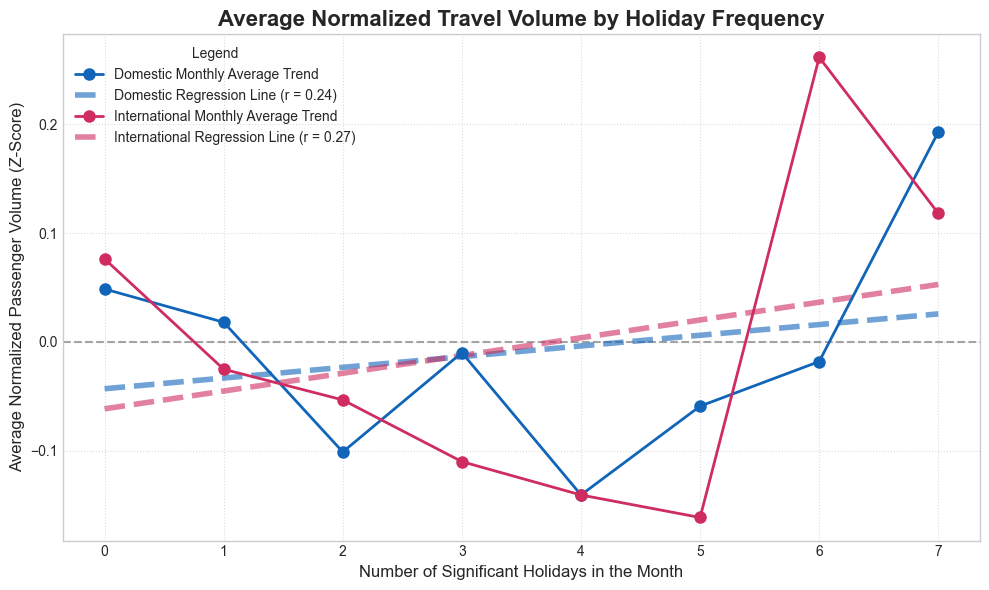

In [6]:
# PLOT

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# DESIGN
line_colors = {'Domestic': "#1165b9", 'International': '#CF2C60'}
max_holidays = filtered_plot1_df['Holiday_Count'].max()
X_plot_unique = filtered_plot1_df['Holiday_Count'].unique()

for flight_type in ['Domestic', 'International']:
    df = filtered_plot1_df[filtered_plot1_df['Flight_Type'] == flight_type]
    Y_avg = df['Avg_ZScore']
    color = line_colors[flight_type]

    current_corr = corr_dom if flight_type == 'Domestic' else corr_int

    # INTERPOLATING LINE
    ax.plot(
        df['Holiday_Count'],
        Y_avg,
        color=color,
        marker='o',
        markersize=8,
        linestyle='-',
        linewidth=2,
        label=f'{flight_type} Monthly Average Trend',
        zorder=3
    )

    # LEAST SQUARES SOLUTION
    P = np.polyfit(df['Holiday_Count'], Y_avg, 1)

    # PLOT LEAST SQUARE LINE
    ax.plot(
        X_plot_unique,
        np.polyval(P, X_plot_unique),
        color=color,
        linewidth=4,
        linestyle='--',
        alpha=0.6,
        label=f'{flight_type} Regression Line (r = {current_corr:.2f})',
        zorder=2
    )

ax.set_title('Average Normalized Travel Volume by Holiday Frequency', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Significant Holidays in the Month', fontsize=12)
ax.set_ylabel('Average Normalized Passenger Volume (Z-Score)', fontsize=12)

# Z = 0 LINE
ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

ax.set_xticks(range(0, int(max_holidays) + 1))
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(title='Legend', loc='upper left')

plt.tight_layout()
plt.show()

#### **Discussion**
Our correlation analysis indicates that the volume of air traffic is not linearly related to the number of significant holidays in a month. Both the Domestic (r = 0.24) and International (r = 0.27) datasets exhibit only a mild positive correlation when comparing average Z-scores. These weak coefficients suggest that the frequency of holidays alone is insufficient to explain or predict variations in travel volume.

Interestingly, despite the positive correlation values, a visual inspection of the data reveals a gradual decrease in travel volume as the number of holidays increases from one to five per month. This trend directly contradicts the direction implied by the correlation coefficients, suggesting that the relationships have likely been distorted by outlier values or uneven data distribution.

This observation could be explained by findings from prior studies, which emphasize that travel demand is more strongly influenced by how holidays are clustered rather than their total count. Specifically, extended breaks or “long weekends” tend to stimulate travel more significantly than isolated single-day holidays, as they provide greater convenience and incentive for leisure trips (ECMT, 2000).


# PLOT 2

#### **Choice of Visualisation and Rationale**
This second visualisation aims to compare the average domestic and international travellers during holiday months across countries, helping us understand travel behaviour and how countries’ domestic and international travel are affected during holiday months.

To prepare the data for this comparison, we began by adding a binary column `is_holiday_month` to a copy of our cleaned dataset which marked months with at least one holiday as 1 and those with no holidays at all as 0. We then filtered the dataset to include holiday months only and used `groupby()` to aggregate the average domestic, international and total passenger counts by country name (`ADM_name`). The resulting summary table was stored in `plot2_df_monthly_hols`. We then added a `gap` column which represents the difference between average domestic and international travel volumes. We decided to use this column to sort the countries on the vertical axis of the plot in terms of the ascending gap from the difference between domestic and international air passengers.

The choice of a dumbbell plot was the most appropriate given the comparison nature of our visualisation, where the visual difference shown in the line segment easily communicates the magnitude and direction of difference clearly and without clutter. A dumbbell plot created using `geom_point()` to mark domestic and international travellers and `geom_segment()` to create the lines in the dumbbell equivalent to the `gap` variable, allows for straightforward comparison of the two travel types within the same country while preserving readability across many observations. The horizontal orientation and colour-coded markers improve clarity by making patterns and gaps easy to spot (e.g. countries with much more significant domestic travel).


In [7]:
plot2_df = data_use.copy()
plot2_df["is_holiday_month"] = plot2_df["Holiday_Count"] > 0 # Mark months with at least 1 holiday

#group based on name and find mean of domestic, international and total
plot2_df_monthly_hols = (
    plot2_df.groupby(["ADM_name"])[["Domestic", "International", "Total"]]
    .mean()
    .reset_index()
)


#add a gap column for domestic vs international
plot2_df_monthly_hols["gap"] = plot2_df_monthly_hols["Domestic"] - plot2_df_monthly_hols["International"]

#sort order of lollipop based on size of gap
order = plot2_df_monthly_hols.sort_values("gap")["ADM_name"]
plot2_df_monthly_hols["ADM_name"] = pd.Categorical(plot2_df_monthly_hols["ADM_name"], categories=order, ordered=True)


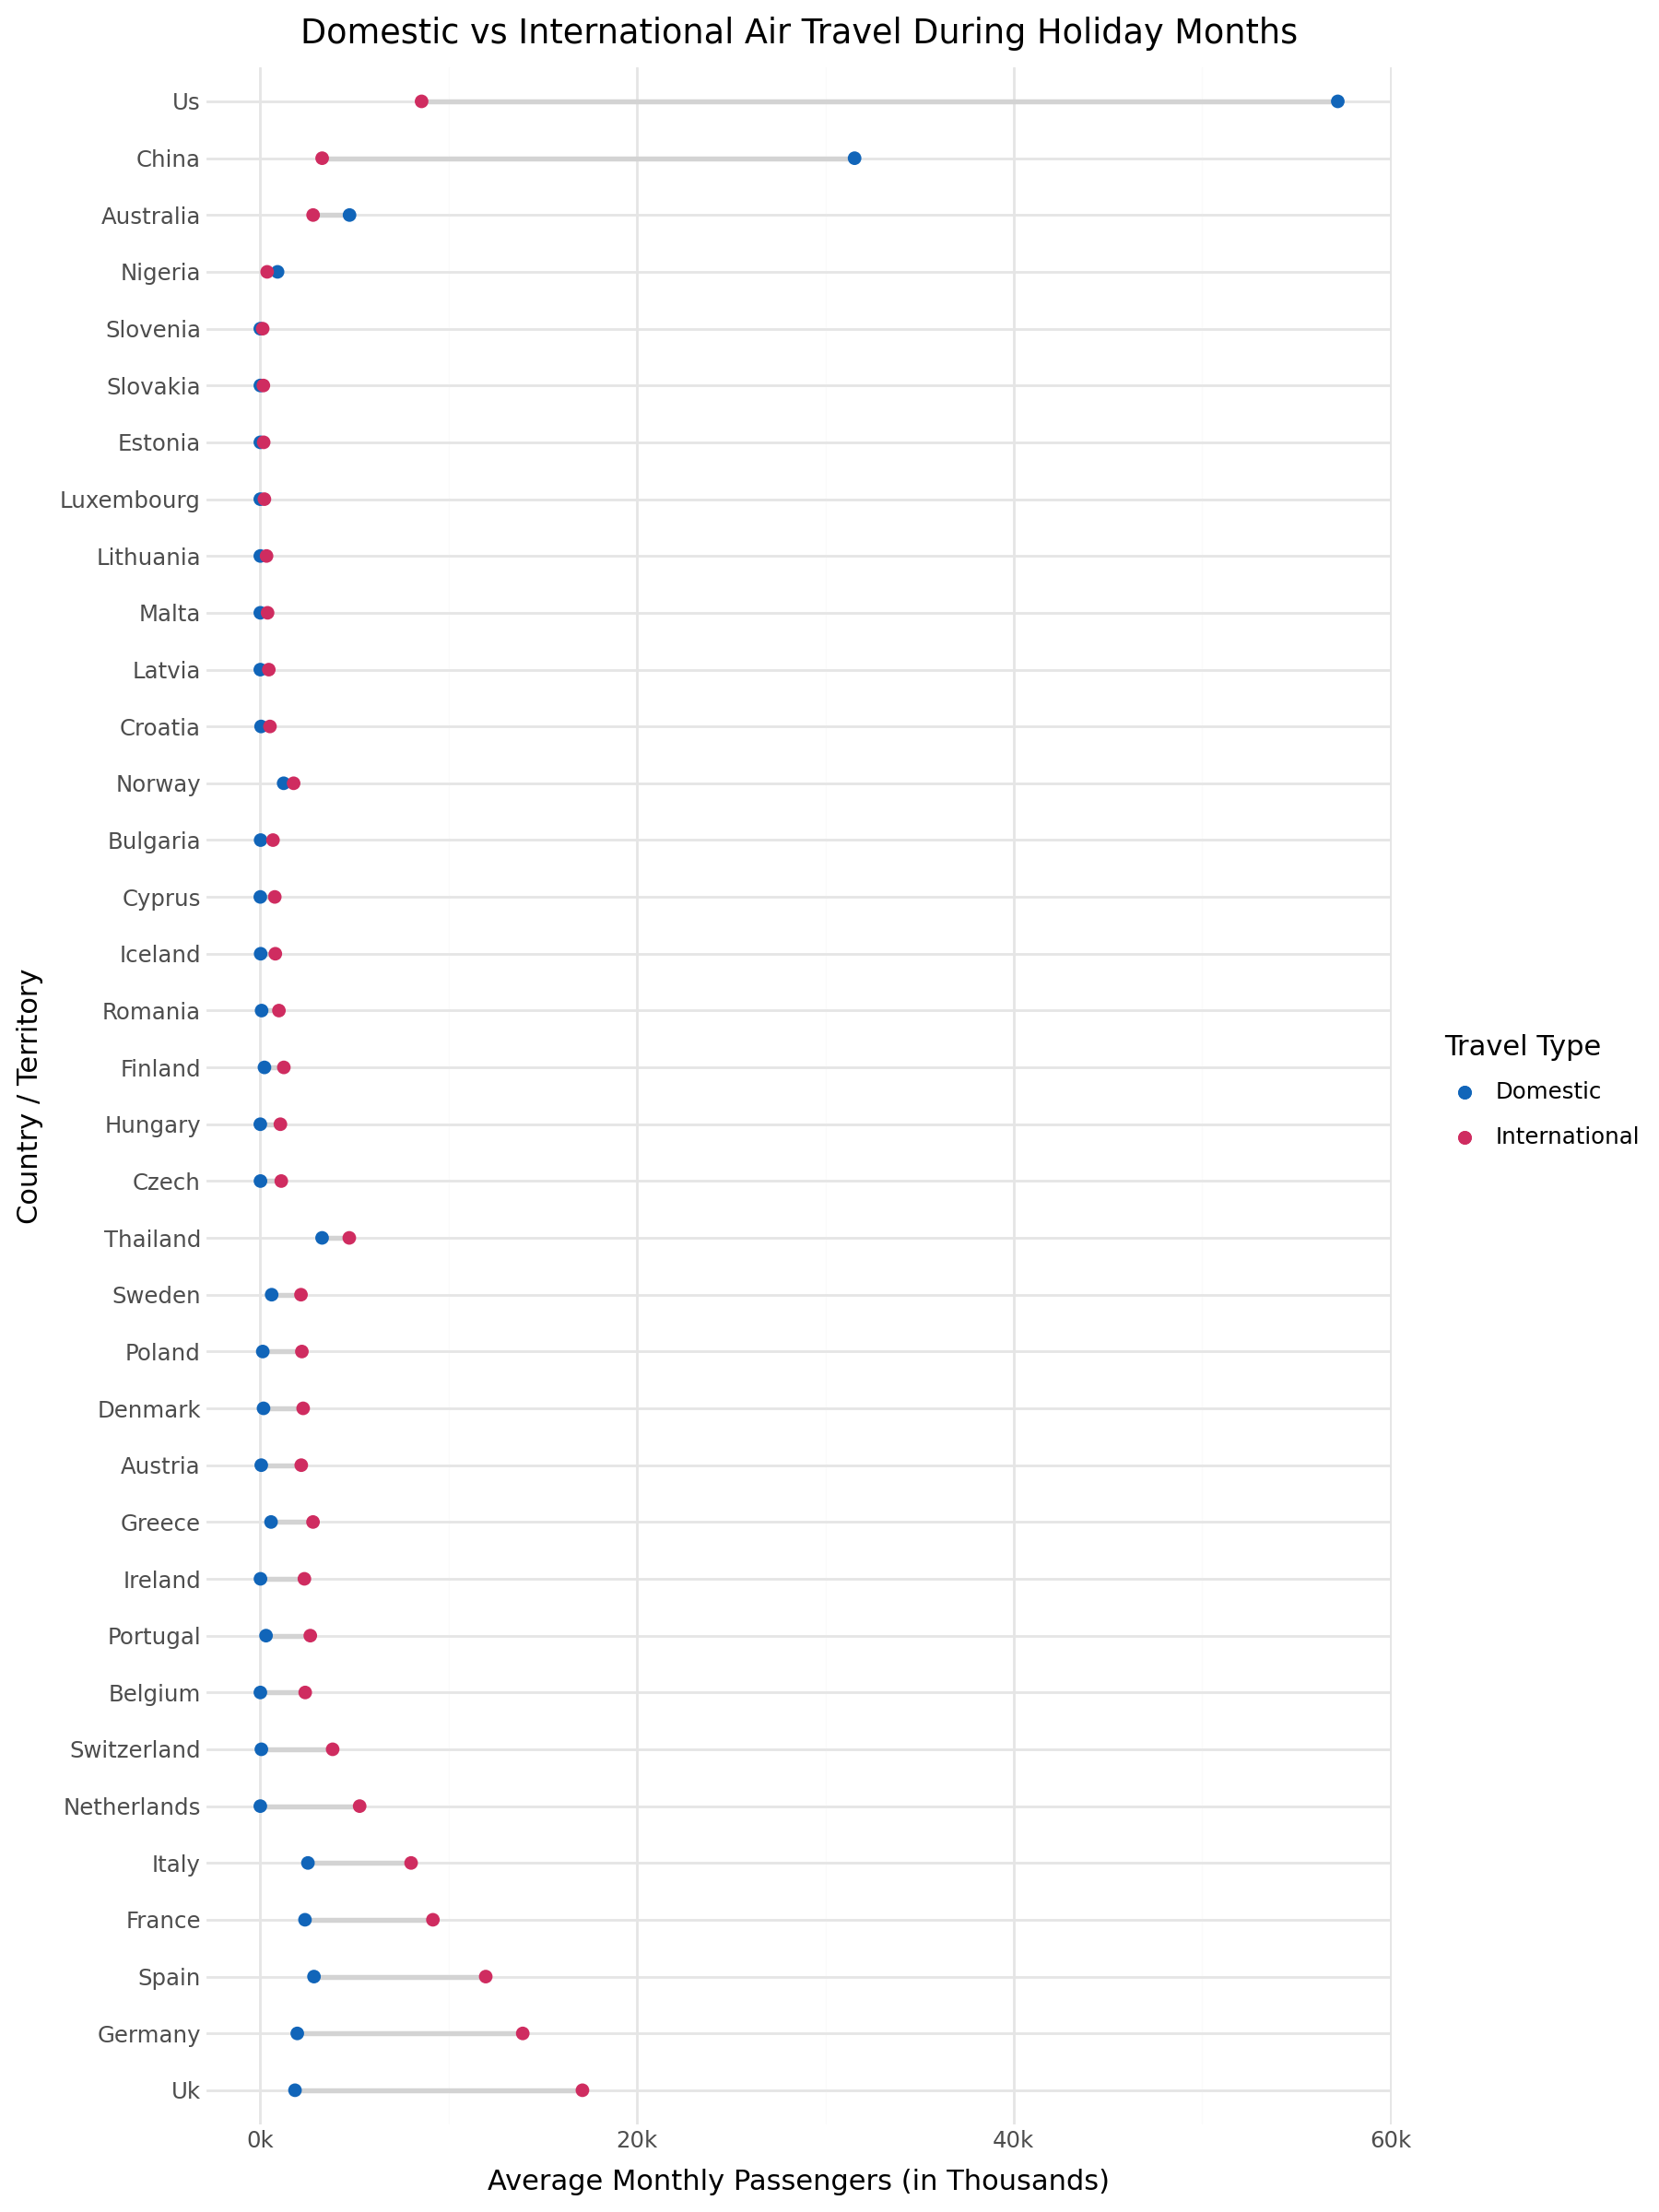

In [8]:
#PLOT

(ggplot(plot2_df_monthly_hols)
# connector lines of the lollipop
+ geom_segment(
    aes(y="ADM_name", yend="ADM_name", x="Domestic", xend="International"),
    color="lightgray", size=1.1)
# points
+ geom_point(aes(x="Domestic", y="ADM_name", color='"Domestic"'), size = 2)
+ geom_point(aes(x="International", y="ADM_name", color='"International"'), size = 2)
# labels / theme
+ labs(title="Domestic vs International Air Travel During Holiday Months",
        x="Average Monthly Passengers (in Thousands)",
        y="Country / Territory",
        color="Travel Type")
+ scale_x_continuous(labels=lambda v: [f"{int(x/1000)}k" for x in v])  # so that its every 10k passengers
+ scale_color_manual(values={"Domestic": "#1165b9", "International": "#CF2C60"})
+ theme_minimal()
+ theme(figure_size=(9, 12)))

#### **Discussion**
Understanding how domestic and international travel behave during holiday months helps contextualise the broader impact of holidays on overall travel activity. When looking at the patterns in our visualization, we can see that domestic air travel dominates international air travel for countries like the United States (US) and China. On the other hand, international air travel exceeds domestic air travel for countries like the United Kingdom (UK), Germany and Spain.

Countries like the US and China have far more domestic passengers possibly due to their extensive and wide internal distances within the country. Considering the large size of such countries with many cities and states within each country, domestic air travel is bound to be substantial during holiday months, with people feeling more inclined to travel across cities that are spread apart, but still within their own country. Not only that, the US and China have extensive domestic airline networks that connect major cities within the country for domestic flights. On the other hand, countries like the UK, Germany and Spain have more international air passengers since European countries tend to focus and promote more on tourism for economic growth. As such, the high influx of tourists during holiday months is reflected in greater international air travel. For most of the other countries, the distinction between domestic and international air travel does not seem to affect the average monthly air passengers as much. This could be due to a balanced mix of domestic and international passengers, paired with the fact that the total air travel volume is relatively low compared to larger countries, so the differences in air passengers are not as visually apparent.


# PLOT 3

#### **Choice of Visualisation and Rationale**

The third visualisation aims to identify global patterns in month-over-month travel behaviour by examining how many countries experience increases or decreases in total air travel in each month and year. We drop dataset from 2019 as it is incomplete and only 1 country (China) reported data for year 2019.

To prepare the data for this analysis, we began by computing the month-over-month percentage changes in total travellers for each country using `groupby([“ISO3])` and `shift(1)` to obtain the previous month’s value. This allowed us to easily compute `pct_change`, the month-over-month percentage difference in passenger volume. Based on these values, we generated two binary columns, `inc` and `dec`, which marked increases in total travellers greater than 5% and decreases in total travellers greater than 5% compared to the previous month. This helped us to focus on only meaningful shifts in travellers. Rows without prior-month data were dropped to ensure valid comparisons.

Next, we aggregated these indicators at the global level. Using `groupby(["Year", "Month"])`, we computed the number of countries with valid data each month, along with the counts of countries showing increases and decreases (`num_increase` and `num_decrease`). These summaries were then transformed into a month-by-year matrix using `pivot()`, producing two separate tables capturing global increases and global decreases. These transformed datasets served as the basis for our pair of heatmaps.
Heatmaps were chosen because they are effective for visualising temporal patterns across multiple years. The colour gradients allow us to quickly identify months where many countries simultaneously experienced elevated travel (e.g., summer peaks) or significant declines (e.g., post-holiday slowdowns). By placing the increase and decrease heatmaps side by side, we are also able to observe contrasts and seasonal cycles in global travel behaviour. This visualisation thus provides a clear, intuitive overview of worldwide aviation trends and how they evolve across months and years.


In [9]:
plot3_df = data_use.copy()
plot3_df = plot3_df.sort_values(["ISO3", "Year", "Month"])

plot3_df= plot3_df[plot3_df["Year"]!=2019]

# month over month change in travellers within each country
plot3_df["Total_prev"] = plot3_df.groupby("ISO3")["Total"].shift(1)
plot3_df["pct_change"]  = (plot3_df["Total"] - plot3_df["Total_prev"])/plot3_df["Total_prev"]
plot3_df["pct_change"] = plot3_df["pct_change"] * 100

# flag major increases and decreases (only those more than 5%)
plot3_df["inc"] = (plot3_df["pct_change"] >= 5).astype(int)
plot3_df["dec"] = (plot3_df["pct_change"] <= -5).astype(int)

# aggregate: % of countries (with prior month available) that increased, per Year–Month
plot3_df_agg = (
    plot3_df.dropna(subset=["Total_prev"]) # need a previous month to judge increase
      .groupby(["Year", "Month"])
      .agg(num_countries=("ISO3", "nunique"),
           num_increase  =("inc", "sum"),
           num_decrease = ("dec", "sum"))
      .reset_index()
)


#pivot so easily to plot
plot3_df_pivoted = plot3_df_agg.pivot(index="Month", columns="Year", values=["num_increase", "num_decrease"]).sort_index().reset_index()

#convert to matrice
plot3_df_pivoted_indexed = plot3_df_pivoted.set_index("Month")
increase = plot3_df_pivoted_indexed.xs("num_increase", axis=1, level=0)   # rows=Month, cols=Year
decrease = plot3_df_pivoted_indexed.xs("num_decrease", axis=1, level=0)


In [10]:
pio.renderers.default = 'notebook_connected'

#colour scale to standardise aesthetics across plots
blue_scale = [
    [0.0, "#e6eef9"],  
    [0.5, "#669bdc"],   
    [1.0, "#1165b9"]   
]

red_scale = [
    [0.0, "#fde6e6"],  
    [0.5, "#e97c7c"],   
    [1.0, "#CF2C60"]  
]

#PLOT

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Number of countries with Month-Over-Month Travel Increase", "Number of countries with Month-Over-Month Travel Decrease"),
    horizontal_spacing=0.08
)

fig.add_trace(
    go.Heatmap(
        z=increase.values, x=increase.columns.astype(str), y=increase.index,
        colorscale=blue_scale, colorbar=dict(title="Count"),
        text = [[f"Countries with Increased Travel: {z}" for z in row]for row in increase.values],
        hovertemplate="%{text}<extra></extra>",
        zmin=0, zmax=max(increase.max().max(), decrease.max().max())
    ),
    row=1, col=1
)

fig.add_trace(
    go.Heatmap(
        z=decrease.values, x=decrease.columns.astype(str), y=decrease.index,
        colorscale=red_scale, colorbar=dict(title="Count"),
        text = [[f"Countries with Decreased Travel: {z}" for z in row]for row in decrease.values],
        hovertemplate="%{text}<extra></extra>",
        zmin=0, zmax=max(increase.max().max(), decrease.max().max())
    ),
    row=1, col=2
)

fig.update_layout(
    title = dict(
        text="Global Month-over-Month Travel Changes",
        x=0.5, y = 0.93,          # 0.5 centers the title horizontally
        xanchor='center',
        yanchor='top',
        font=dict(size=20)  # larger title font
    ),
    xaxis_title="Year", xaxis2_title="Year",
    yaxis_title="Month", yaxis2_title="Month",
    template="plotly_white", height=500, margin=dict(l=10, r=10, t=100, b=10)
)
fig.show()


#### **Discussion**
A clear seasonal pattern emerges as shown in the heatmap. Across most years, the months from March to August consistently show the highest number of countries with month-over-month increases in air travel. Importantly, this pattern does not simply reflect the dominance of major aviation markets, but the broader fact that most of the world’s countries and population are located in the Northern Hemisphere, where mid-year travel demand naturally rises; for example, an estimated 87.5% of the global population lives in the Northern Hemisphere, and roughly two-thirds of global landmass lies there (Kummu & Varis, 2011). This geographic imbalance is also reflected in our dataset, which contains 35 Northern Hemisphere countries and only one Southern Hemisphere country (Australia). This pattern aligns with broader aviation dynamics: the three largest air travel regions (Asia-Pacific, Europe, and North America) together account for around 85% of global passenger traffic, and all are located primarily in the Northern Hemisphere (Passenger Recovery Continues in November, n.d.). Their shared seasonal cycles therefore reinforce the global mid-year peak.

In many Northern Hemisphere countries, March to April align with major holiday and travel periods such as Easter, Spring Break, and the start of warmer weather tourism (Spring Break Boosts Global Economy with Tourism Surge, 2025). This is followed by the June to August summer season, which is the busiest global tourism period (Goran Corluka, 2019). According to the UN World Tourism Organization (UNWTO), July and August together account for nearly one-third of all international tourist arrivals worldwide, indicating a strong global tendency toward mid-year travel peaks (UNWTO World Tourism Barometer and Statistical Annex, 2024). Because so many countries share this seasonal pattern, a large number of them show simultaneous increases in monthly air-travel volumes during these months, producing a strong band of increases in the heatmap.

Conversely, the months outside this period (September to February) tend to show more countries with declining month-to-month travel, reflecting the end of summer tourism and the return to work and school cycles in most of the world. The year 2010 shows some deviation from the general pattern, likely due to the major disruption caused by the Eyjafjallajökull volcanic eruption in April 2010, which grounded flights across Europe and depressed global aviation activity (Ulfarsson & Unger, 2011).


# Conclusion
Across our three visualisations, we explored how different holiday periods influence global air-travel behaviour. Rather than treating holidays as uniform events, our analyses considered how the timing, length, and structure of holiday periods shape both domestic and international traveller movement.

Our first visualisation showed that simply counting the number of holidays in a month does not strongly predict travel volume. The weak correlations suggest that isolated or single-day holidays have limited impact on mobility. This highlights that the period characteristics of holidays, such as extended breaks or strategically clustered days off are more influential than holiday frequency alone.

The second visualisation revealed substantial variation in travel patterns during holiday months across countries. Larger countries like the United States and China displayed significantly higher domestic travel during holiday periods, while European countries saw greater international movement. These differences reflect how the structure of holiday periods interacts with country-specific factors such as geography and domestic transport networks.

The global heatmaps provided the clearest evidence of the importance of holiday periods. From March to August, many countries simultaneously experienced sustained increases in travel, aligning with major mid-year holiday periods, notably the long Northern Hemisphere summer school break. Extended school holidays offer families and students greater flexibility to travel, resulting in widespread and prolonged increases in passenger activity. This demonstrates that long, cohesive holiday periods have a far stronger global effect than isolated holidays.

In summary, our findings indicate that it is not the number of holidays, but the nature of the holiday period—its length, clustering, and seasonal timing—that most meaningfully shapes travel activity worldwide. Understanding how different holiday periods influence mobility provides a more accurate perspective on global travel dynamics than analysing holiday counts alone.


# Task Allocation

As a group, we collaboratively brainstormed a range of questions and plots that could help us answer the question. After discussion, we selected our final question and identified the most insightful visualisations to address it. We then divided the project tasks accordingly:

+ Data Cleaning: Terence
+ Figure 1: Shawn
+ Figure 2: Jia En
+ Figure 3: Gabrielle
+ Introduction, Conclusion, Discussions & Formatting: Anthony

# References
European Conference of Ministers of Transport (ECMT). (2000). Transport and Leisure, ECMT Round Tables No. 111. OECD Publishing, Paris. DOI: 10.1787/9789264182370-en.

Goran Corluka, P. (2019). TOURISM SEASONALITY - AN OVERVIEW. Journal of Business Paradigms. https://www.academia.edu/40454689/TOURISM_SEASONALITY_AN_OVERVIEW

Kummu, M., & Varis, O. (2011). The world by latitudes: A global analysis of human population, development level and environment across the north–south axis over the past half century. Applied Geography, 31(2), 495–507. https://doi.org/10.1016/j.apgeog.2010.10.009

Passenger Recovery Continues in November. (n.d.). Retrieved 13 November 2025, from https://www.iata.org/en/pressroom/2023-releases/2023-01-09-02/

R for Data Science Online Learning Community. (2024, December 24). TidyTuesday: 2024-12-24 dataset. GitHub repository. https://github.com/rfordatascience/tidytuesday/tree/main/data/2024/2024-12-24

Spring break boosts global economy with tourism surge. (2025, March 11). https://globaledge.msu.edu/blog/post/59494/spring-break-boosts-global-economy-with

Ulfarsson, G. F., & Unger, E. A. (2011). Impacts and Responses of Icelandic Aviation to the 2010 Eyjafjallajökull Volcanic Eruption: Case Study. Transportation Research Record, 2214(1), 144–151. https://doi.org/10.3141/2214-18
